<a href="https://colab.research.google.com/github/zaraaa12/BigData/blob/main/ChurnAnalysist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape
df.info()
df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [3]:
df.drop("customerID", axis=1, inplace=True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

/tmp/ipython-input-2501913337.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


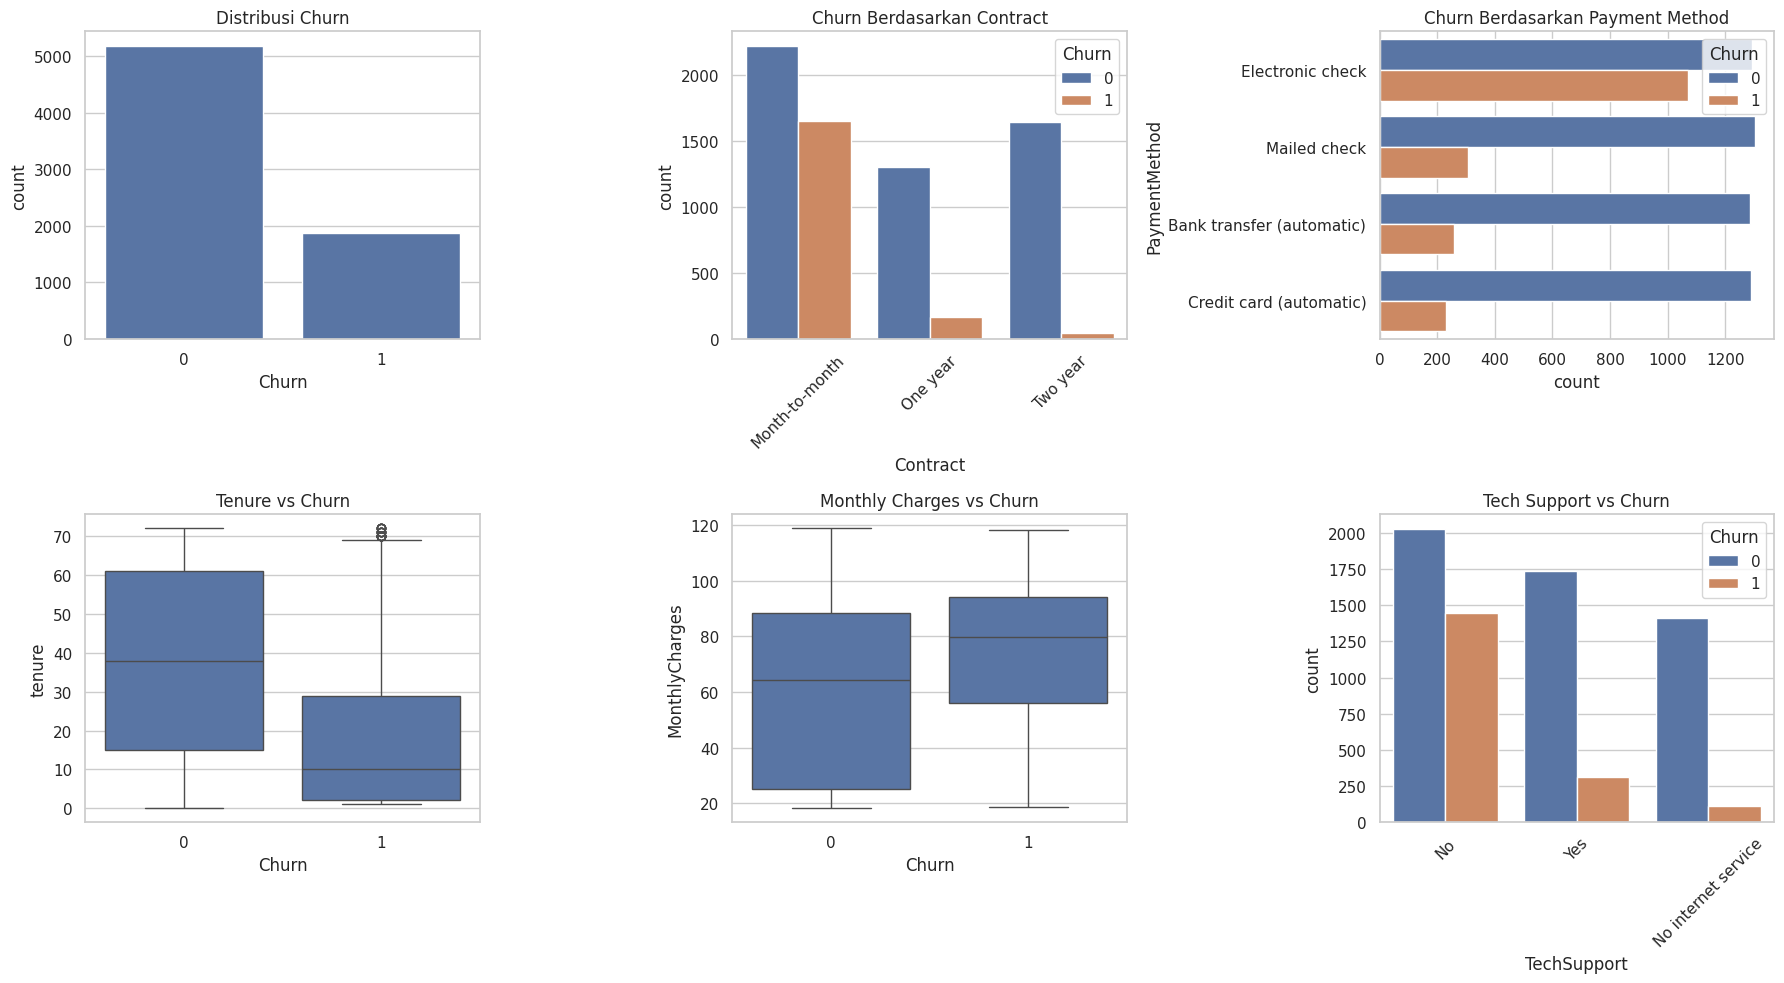

In [7]:
fig, ax = plt.subplots(2, 3, figsize=(18,10))

sns.countplot(x="Churn", data=df, ax=ax[0,0])
ax[0,0].set_title("Distribusi Churn")

sns.countplot(x="Contract", hue="Churn", data=df, ax=ax[0,1])
ax[0,1].set_title("Churn Berdasarkan Contract")
ax[0,1].tick_params(axis='x', rotation=45)

sns.countplot(y="PaymentMethod", hue="Churn", data=df, ax=ax[0,2])
ax[0,2].set_title("Churn Berdasarkan Payment Method")

sns.boxplot(x="Churn", y="tenure", data=df, ax=ax[1,0])
ax[1,0].set_title("Tenure vs Churn")

sns.boxplot(x="Churn", y="MonthlyCharges", data=df, ax=ax[1,1])
ax[1,1].set_title("Monthly Charges vs Churn")

sns.countplot(x="TechSupport", hue="Churn", data=df, ax=ax[1,2])
ax[1,2].set_title("Tech Support vs Churn")
ax[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [18]:
pd.crosstab(df["Contract"], df["Churn"], normalize='index') * 100
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Contract'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(table)

In [9]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize='index') * 100

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [10]:
pd.crosstab(df["TechSupport"], df["Churn"], normalize='index') * 100

Churn,0,1
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [11]:
df_encoded = pd.get_dummies(df, drop_first=True)
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(importance)

                                  Feature  Coefficient
25                      Contract_Two year    -1.399850
10            InternetService_Fiber optic     0.640171
24                      Contract_One year    -0.631767
13                     OnlineSecurity_Yes    -0.471879
7                        PhoneService_Yes    -0.447569
19                        TechSupport_Yes    -0.391451
26                   PaperlessBilling_Yes     0.339982
28         PaymentMethod_Electronic check     0.325780
8          MultipleLines_No phone service     0.266645
23                    StreamingMovies_Yes     0.226834
9                       MultipleLines_Yes     0.219604
15                       OnlineBackup_Yes    -0.213357
0                           SeniorCitizen     0.164732
6                          Dependents_Yes    -0.159346
21                        StreamingTV_Yes     0.128104
14       OnlineBackup_No internet service    -0.098267
16   DeviceProtection_No internet service    -0.098267
20        

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


hasil **Logistic Regression Feature Coefficient** menunjukkan customer dengan kontrak 2 tahun sangat kecil kemungkinan churn sedangkan customer Fiber Optic lebih rentan churn.
Disebabkan karena harga lebih mahal dan ekspektasi kualitas tinggi.

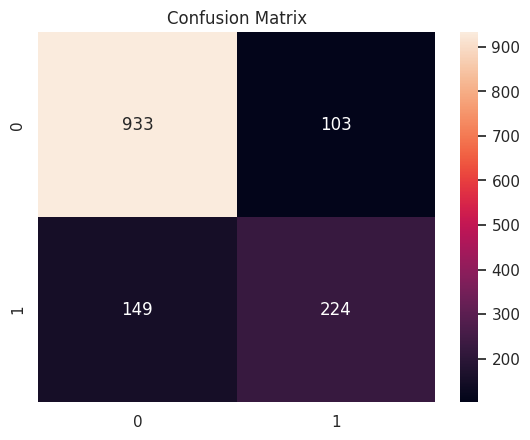

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [14]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8211497515968772

**BUSINESS INSIGHT**

Berdasarkan hasil analisis, untuk memperkuat flow bisnis dorong customer pindah ke kontrak tahunan, tingkatkan kualitas Fiber Optic, bundling Tech Support + Online Security serta kurangi electronic check, lalu arahkan auto payment.